## Univariate Data Analysis

In [28]:
# setup
! pip install --upgrade pip
! pip install numpy pandas

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

plt.rcParams['figure.dpi']     = 130
sns.set_theme(style='whitegrid', palette='muted')

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
GRAY   = '#888780'

def skew_label(s):
    if   s >  1: return 'strong right skew → log-transform'
    elif s > 0.5: return 'moderate right skew'
    elif s < -1: return 'strong left skew'
    else:        return 'approx. normal'

In [30]:
df = pd.read_csv("./data/dompet_final_cleaned_v2.csv")
print(f"Working dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")

Working dataset: 4,154 rows × 43 cols


In [31]:
# seller_joined_date: likely stored as float (epoch days or timestamp)
if df['seller_joined_date'].dtype != 'datetime64[ns]':
    try:
        df['seller_joined_date'] = pd.to_datetime(df['seller_joined_date'], unit='s')
        print("seller_joined_date → parsed as Unix timestamp (seconds)")
    except:
        df['seller_joined_date'] = pd.to_datetime(df['seller_joined_date'])
        print("seller_joined_date → parsed as datetime string")

# voucher_status: treat as categorical flag (0/1)
df['voucher_status'] = df['voucher_status'].astype('int8')

# video_count: should be int
df['video_count'] = df['video_count'].fillna(0).astype('int8')

# Categorical string cols — strip whitespace & normalise case
cat_cols = ['leather_texture', 'leather_finish', 'leather_type',
            'shipped_from_region', 'wallet_type']
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

print("\nTypes after corrections:")
print(df[cat_cols + ['seller_joined_date', 'voucher_status', 'video_count']].dtypes)

seller_joined_date → parsed as datetime string

Types after corrections:
leather_texture                object
leather_finish                 object
leather_type                   object
shipped_from_region            object
wallet_type                    object
seller_joined_date     datetime64[ns]
voucher_status                   int8
video_count                      int8
dtype: object


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4154 entries, 0 to 4153
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   id                                 4154 non-null   int64         
 1   title                              4154 non-null   object        
 2   rating                             4154 non-null   float64       
 3   reviews                            4154 non-null   int64         
 4   initial_price                      4154 non-null   float64       
 5   final_price                        4154 non-null   float64       
 6   stock                              4154 non-null   int64         
 7   favorite                           4154 non-null   int64         
 8   seller_name                        4154 non-null   object        
 9   breadcrumb                         4154 non-null   object        
 10  seller_rating                      4

In [33]:
# ── Quick numeric summary with skew & kurtosis ────────────────────
num_cols = [
    'rating', 'reviews', 'final_price', 'initial_price',
    'stock', 'favorite', 'sold', 'gmv_cal',
    'seller_followers', 'seller_products',
    'seller_chats_responded_percentage', 'discount',
    'image_count', 'video_count', 'variations_count',
]

summary = df[num_cols].agg(['mean','median','std','min','max']).T
summary['skewness']  = df[num_cols].skew()
summary['kurtosis']  = df[num_cols].kurt()
summary['transform'] = summary['skewness'].apply(skew_label)

display(summary.style
    .background_gradient(subset=['skewness'], cmap='RdYlGn_r')
    .set_caption('Univariate summary — numeric features')
    .format({'mean':'{:,.1f}', 'median':'{:,.1f}', 'std':'{:,.1f}',
             'min':'{:,.1f}', 'max':'{:,.1f}',
             'skewness':'{:.2f}', 'kurtosis':'{:.2f}'})
)

,mean,median,std,min,max,skewness,kurtosis,transform
rating,4.8,4.9,0.3,0.0,5.0,-8.86,125.81,strong left skew
reviews,451.8,29.0,"2,109.2",0.0,"49,830.0",12.26,200.91,strong right skew → log-transform
final_price,"83,143.5","70,000.0","60,346.8","3,999.0","600,000.0",2.53,10.06,strong right skew → log-transform
initial_price,"141,230.4","130,000.0","99,703.2","5,000.0","1,339,000.0",2.81,15.01,strong right skew → log-transform
stock,"2,227.5",92.0,"30,840.1",0.0,"1,727,036.0",46.24,2437.02,strong right skew → log-transform
favorite,114.1,26.0,198.0,0.0,997.0,2.45,5.67,strong right skew → log-transform
sold,750.3,67.0,"2,520.0",0.0,"54,813.0",9.69,140.72,strong right skew → log-transform
gmv_cal,"49,213,871.7","4,593,625.0","196,104,962.4",0.0,"5,746,629,000.0",13.66,284.79,strong right skew → log-transform
seller_followers,"139,004.5","28,600.0","203,686.8",0.0,"1,266,960.0",1.61,1.59,strong right skew → log-transform
seller_products,346.5,285.0,261.5,5.0,"4,356.0",2.29,18.91,strong right skew → log-transform


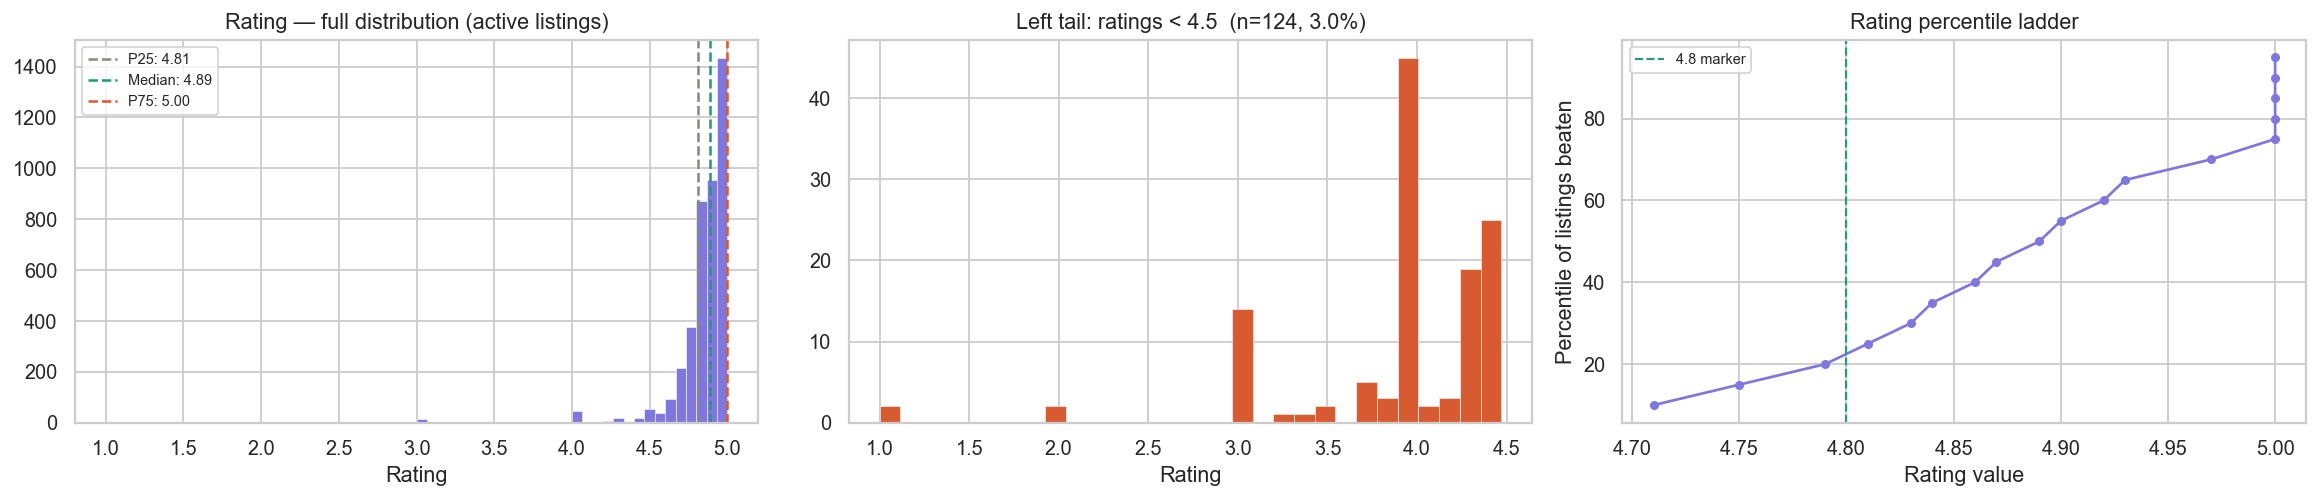


── Rating thresholds (active listings only) ──
  P25: 4.810
  P50: 4.890
  P75: 5.000
  P90: 5.000
  P95: 5.000


In [34]:
# ── Rating is the most important roadmap variable ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

active = df[df['rating'] > 0]  # exclude inactive listings

# (a) Full histogram
axes[0].hist(active['rating'], bins=60, color=PURPLE, edgecolor='white', lw=0.3)
for pct, col, lbl in [(25, GRAY, 'P25'), (50, TEAL, 'Median'), (75, CORAL, 'P75')]:
    v = np.percentile(active['rating'], pct)
    axes[0].axvline(v, color=col, lw=1.4, linestyle='--', label=f'{lbl}: {v:.2f}')
axes[0].set_title('Rating — full distribution (active listings)')
axes[0].set_xlabel('Rating')
axes[0].legend(fontsize=8)

# (b) Left-tail zoom: ratings below 4.5 — the "danger zone"
danger = active[active['rating'] < 4.5]
axes[1].hist(danger['rating'], bins=30, color=CORAL, edgecolor='white', lw=0.3)
axes[1].set_title(f'Left tail: ratings < 4.5  (n={len(danger):,}, {len(danger)/len(active)*100:.1f}%)')
axes[1].set_xlabel('Rating')

# (c) Percentile ladder — what rating do you need to beat X% of listings?
pcts = range(10, 100, 5)
vals = [np.percentile(active['rating'], p) for p in pcts]
axes[2].plot(vals, list(pcts), color=PURPLE, marker='o', ms=4, lw=1.5)
axes[2].axvline(4.8, color=TEAL, lw=1.2, linestyle='--', label='4.8 marker')
axes[2].set_xlabel('Rating value')
axes[2].set_ylabel('Percentile of listings beaten')
axes[2].set_title('Rating percentile ladder')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print key roadmap thresholds
print("\n── Rating thresholds (active listings only) ──")
for p in [25, 50, 75, 90, 95]:
    print(f"  P{p:2d}: {np.percentile(active['rating'], p):.3f}")


#### [Insight] Rating distribution is extremely left-compressed — most listings cluster between 4.7–5.0. The P25 sits on 4.81. This means even a 4.6 rating puts a seller in the bottom quartile. The percentile ladder plot directly feeds the roadmap statement, for example, "Seller needs to have > 4.95 to be in the top 25% of wallet listings. 

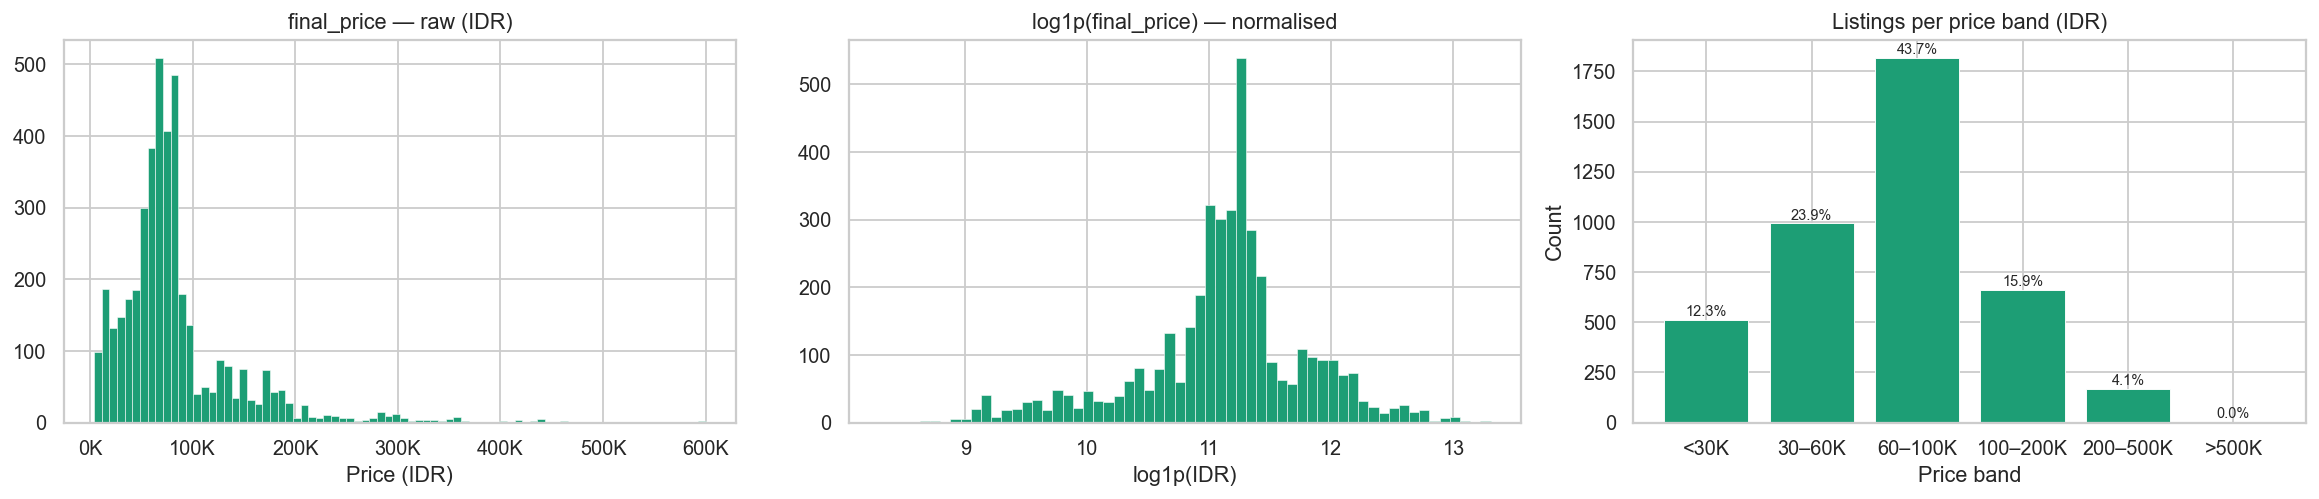


── Price band breakdown ──
            count   pct
price_band             
<30K          510  12.3
30–60K        993  23.9
60–100K      1817  43.7
100–200K      662  15.9
200–500K      170   4.1
>500K           2   0.0


In [35]:
# ── Price: raw is unreadable, log reveals the true shape ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (a) Raw final_price — will show extreme right skew
axes[0].hist(df['final_price'], bins=80, color=TEAL, edgecolor='white', lw=0.3)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[0].set_title('final_price — raw (IDR)')
axes[0].set_xlabel('Price (IDR)')

# (b) log1p final_price
axes[1].hist(np.log1p(df['final_price']), bins=60, color=TEAL, edgecolor='white', lw=0.3)
axes[1].set_title('log1p(final_price) — normalised')
axes[1].set_xlabel('log1p(IDR)')

# (c) Price band segmentation — count listings per band
bins_idr  = [0, 30000, 60000, 100000, 200000, 500000, float('inf')]
labels_idr = ['<30K', '30–60K', '60–100K', '100–200K', '200–500K', '>500K']
df['price_band'] = pd.cut(df['final_price'], bins=bins_idr, labels=labels_idr)
band_counts = df['price_band'].value_counts().sort_index()
axes[2].bar(band_counts.index, band_counts.values, color=TEAL, edgecolor='white', lw=0.5)
for i, (idx, cnt) in enumerate(band_counts.items()):
    axes[2].text(i, cnt + 20, f'{cnt/len(df)*100:.1f}%', ha='center', fontsize=8)
axes[2].set_title('Listings per price band (IDR)')
axes[2].set_xlabel('Price band')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n── Price band breakdown ──")
print(band_counts.to_frame(name='count').assign(pct=lambda x: (x['count']/len(df)*100).round(1)))

#### [Insight] Majority of wallet listings are clustered in the 30-100K band. The log plot reveals a near-bimodal shape (budget segment vs premium segment). 

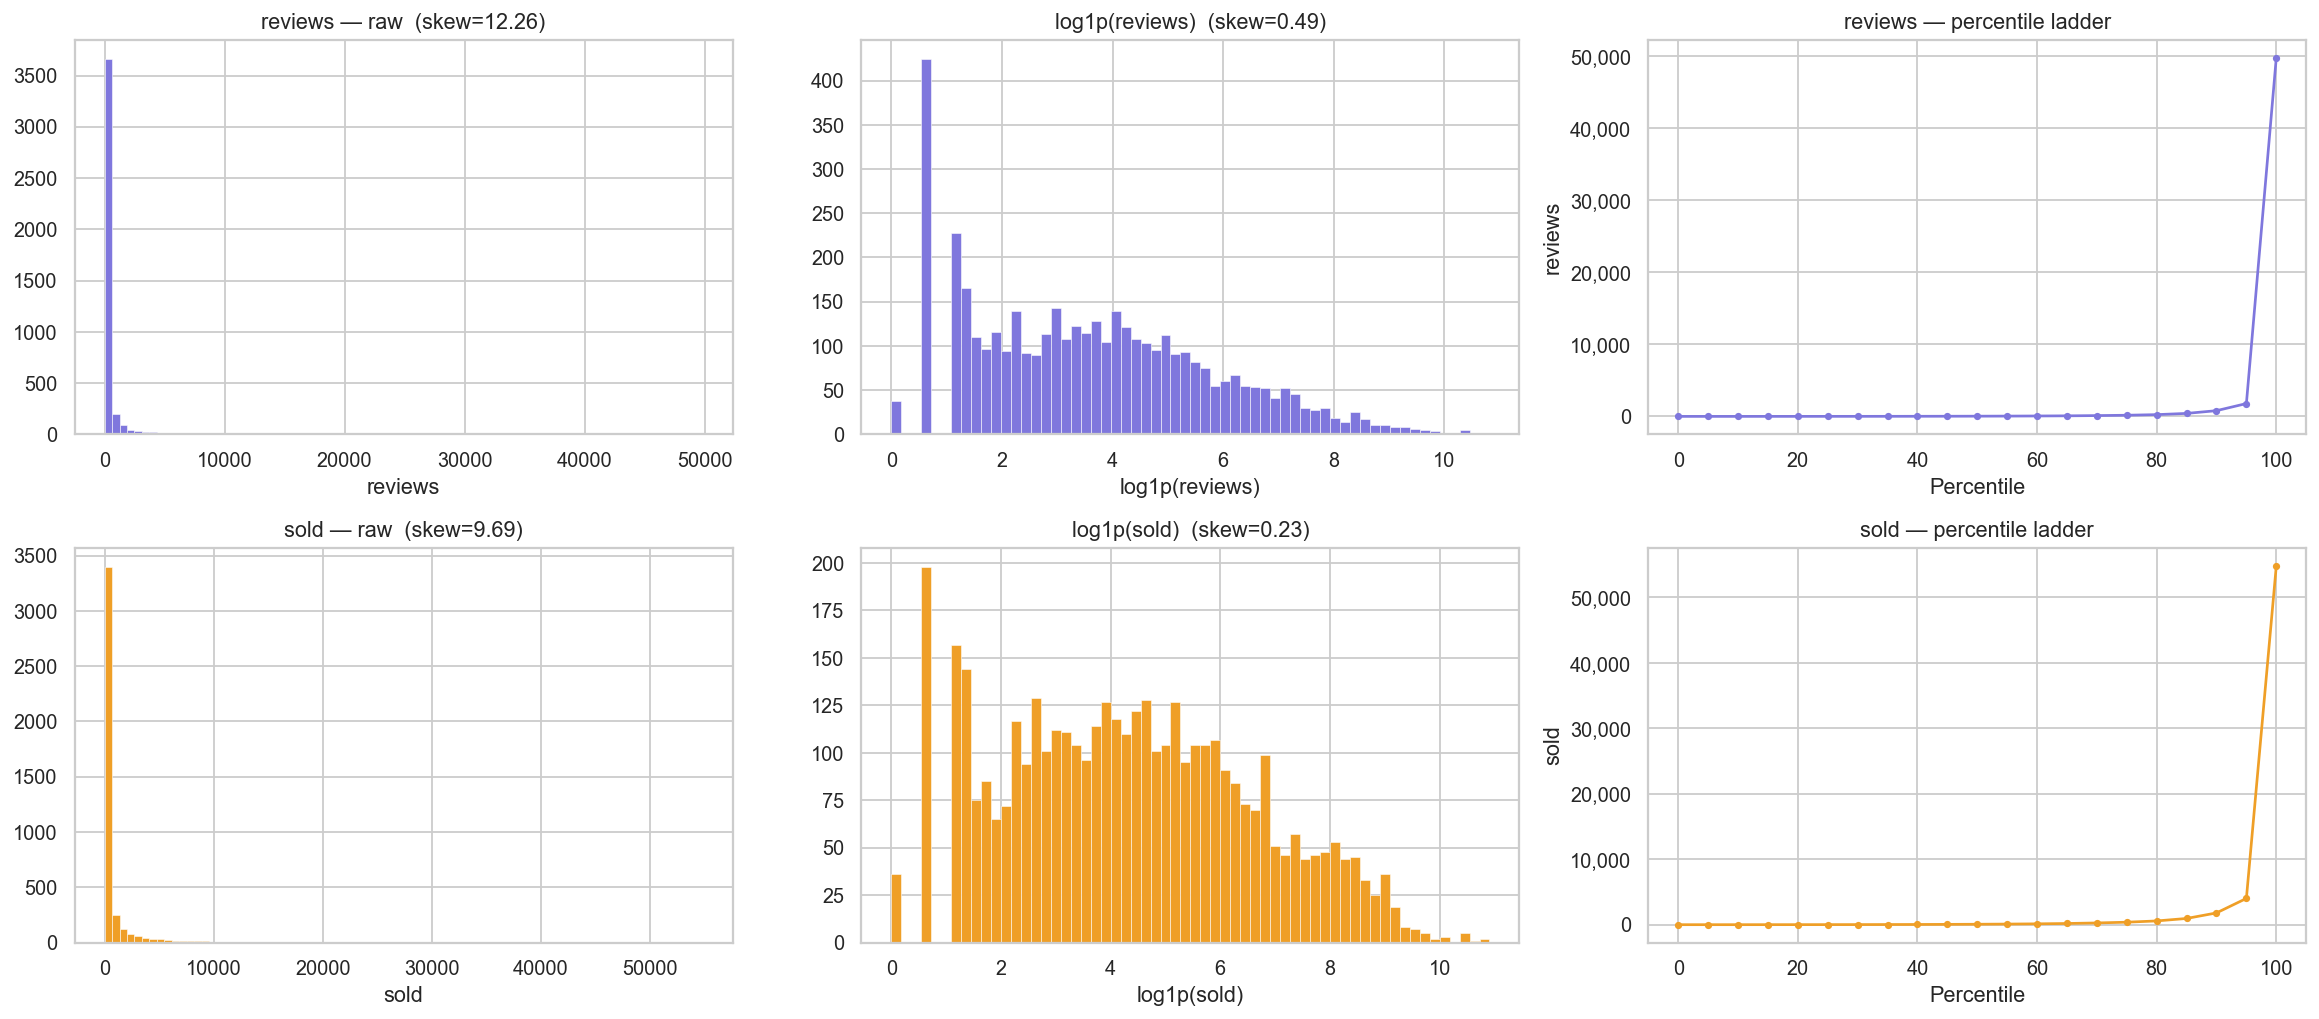


── Reviews & sold: key percentiles ──

  reviews (n=4,116 with >0):
    P25: 6
    P50: 31
    P75: 161
    P90: 796
    P95: 1,783
    P99: 7,849

  sold (n=4,118 with >0):
    P25: 12
    P50: 69
    P75: 382
    P90: 1,800
    P95: 4,015
    P99: 9,483


In [36]:
# ── Reviews and sold are the most right-skewed columns ────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for row, col in enumerate(['reviews', 'sold']):
    raw = df[col]
    log_col = f'log_{col}'
    if log_col in df.columns:
        log_v = df[log_col]
    else:
        log_v = np.log1p(raw)

    color = PURPLE if col == 'reviews' else AMBER

    # Raw
    axes[row, 0].hist(raw, bins=80, color=color, edgecolor='white', lw=0.3)
    axes[row, 0].set_title(f'{col} — raw  (skew={raw.skew():.2f})')
    axes[row, 0].set_xlabel(col)

    # Log
    axes[row, 1].hist(log_v, bins=60, color=color, edgecolor='white', lw=0.3)
    axes[row, 1].set_title(f'log1p({col})  (skew={log_v.skew():.2f})')
    axes[row, 1].set_xlabel(f'log1p({col})')

    # Percentile ladder
    pcts = list(range(0, 101, 5))
    vals = [np.percentile(raw[raw > 0], p) for p in pcts]
    axes[row, 2].plot(pcts, vals, color=color, marker='o', ms=3, lw=1.5)
    axes[row, 2].set_xlabel('Percentile')
    axes[row, 2].set_ylabel(col)
    axes[row, 2].set_title(f'{col} — percentile ladder')
    axes[row, 2].yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Reviews & sold: key percentiles ──")
for col in ['reviews', 'sold']:
    active_col = df[df[col] > 0][col]
    print(f"\n  {col} (n={len(active_col):,} with >0):")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"    P{p:2d}: {np.percentile(active_col, p):,.0f}")

#### [Insight] Reviews (skew=12.22 → 0.50 after log): The raw distribution shows the vast majority of wallet listings have near-zero reviews, with a tiny elite driving the extreme right tail up to 50,000. The log transform reveals a bimodal shape — there's a distinct gap between "essentially unlisted" products (log1p ≈ 0–1, i.e. 0–1 reviews) and "gaining traction" products (log1p ≥ 2, i.e. 7+ reviews), suggesting two fundamentally different seller states rather than a smooth continuum.

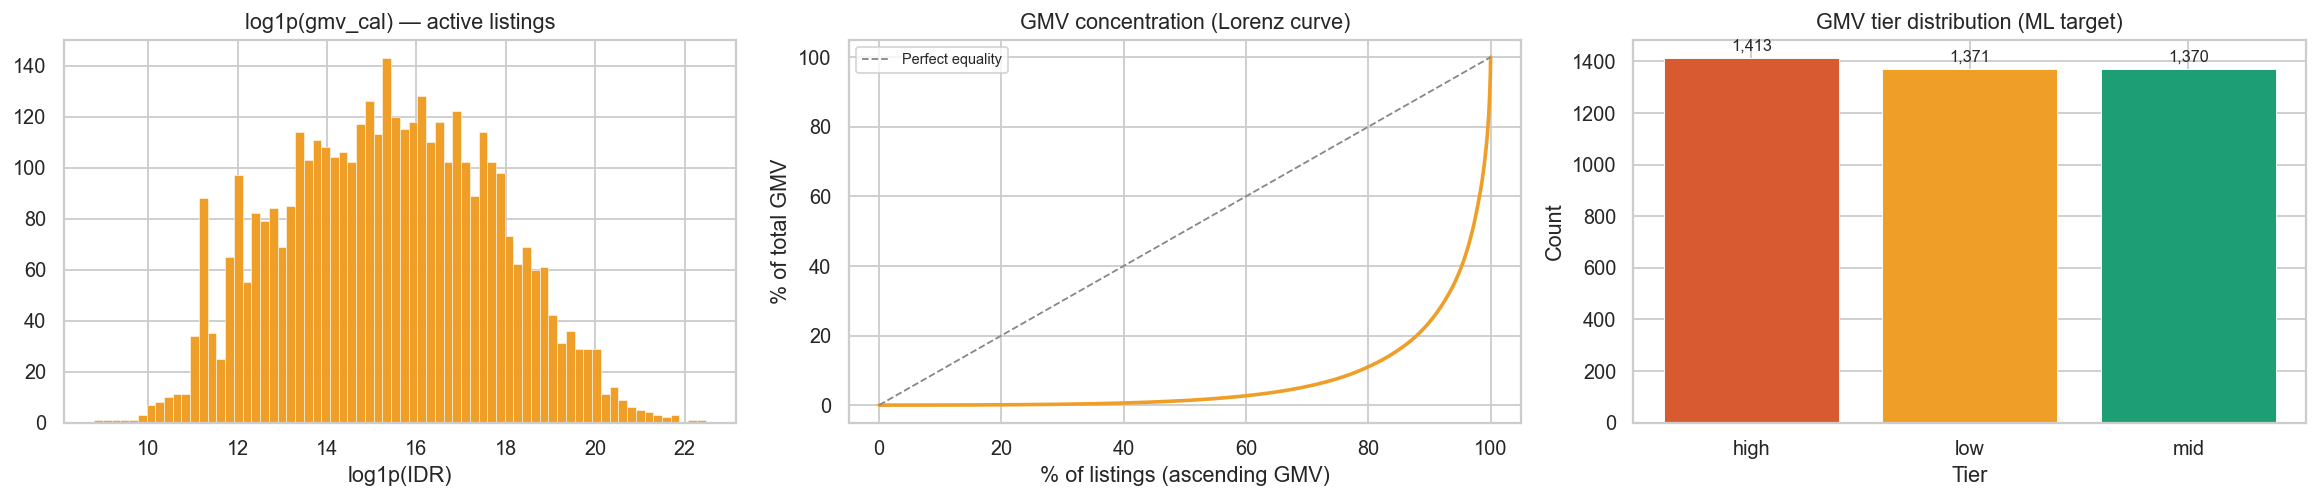


── GMV tier boundaries (IDR) ──
                     min          median                max
gmv_tier                                                   
low                IDR 0     IDR 356,000      IDR 1,417,500
mid        IDR 1,420,200   IDR 4,500,000     IDR 13,720,000
high      IDR 13,795,000  IDR 49,749,000  IDR 5,746,629,000


/var/folders/g_/fmz6fbfx0l96hfjsv2764ypw0000gn/T/ipykernel_3612/264697763.py:44: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f'IDR {x:,.0f}'))


In [37]:
# ── GMV is the ultimate success metric ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

gmv = df['gmv_cal']
gmv_pos = gmv[gmv > 0]

# (a) Log GMV histogram
axes[0].hist(np.log1p(gmv_pos), bins=70, color=AMBER, edgecolor='white', lw=0.3)
axes[0].set_title('log1p(gmv_cal) — active listings')
axes[0].set_xlabel('log1p(IDR)')

# (b) Lorenz-style: cumulative GMV share
sorted_gmv = np.sort(gmv_pos.values)
cum_gmv    = np.cumsum(sorted_gmv) / sorted_gmv.sum()
cum_pct    = np.linspace(0, 1, len(sorted_gmv))
axes[1].plot(cum_pct * 100, cum_gmv * 100, color=AMBER, lw=2)
axes[1].plot([0,100],[0,100], color=GRAY, lw=1, linestyle='--', label='Perfect equality')
axes[1].set_xlabel('% of listings (ascending GMV)')
axes[1].set_ylabel('% of total GMV')
axes[1].set_title('GMV concentration (Lorenz curve)')
axes[1].legend(fontsize=8)

# (c) GMV tier labels for ML target
df['gmv_tier'] = pd.qcut(
    df['gmv_cal'], q=[0, .33, .66, 1],
    labels=['low', 'mid', 'high'],
    duplicates='drop'
)
tier_counts = df['gmv_tier'].value_counts()
axes[2].bar(tier_counts.index, tier_counts.values,
            color=[CORAL, AMBER, TEAL], edgecolor='white', lw=0.5)
for i, (idx, cnt) in enumerate(tier_counts.items()):
    axes[2].text(i, cnt + 30, f'{cnt:,}', ha='center', fontsize=9)
axes[2].set_title('GMV tier distribution (ML target)')
axes[2].set_xlabel('Tier')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# GMV tier boundaries
print("\n── GMV tier boundaries (IDR) ──")
print(df.groupby('gmv_tier', observed=True)['gmv_cal'].agg(['min','median','max'])
      .applymap(lambda x: f'IDR {x:,.0f}'))

#### [Insight] The Lorenz curve shows the top 10% of listings generating 60–80% of total GMV reflecting the classic Pareto distribution

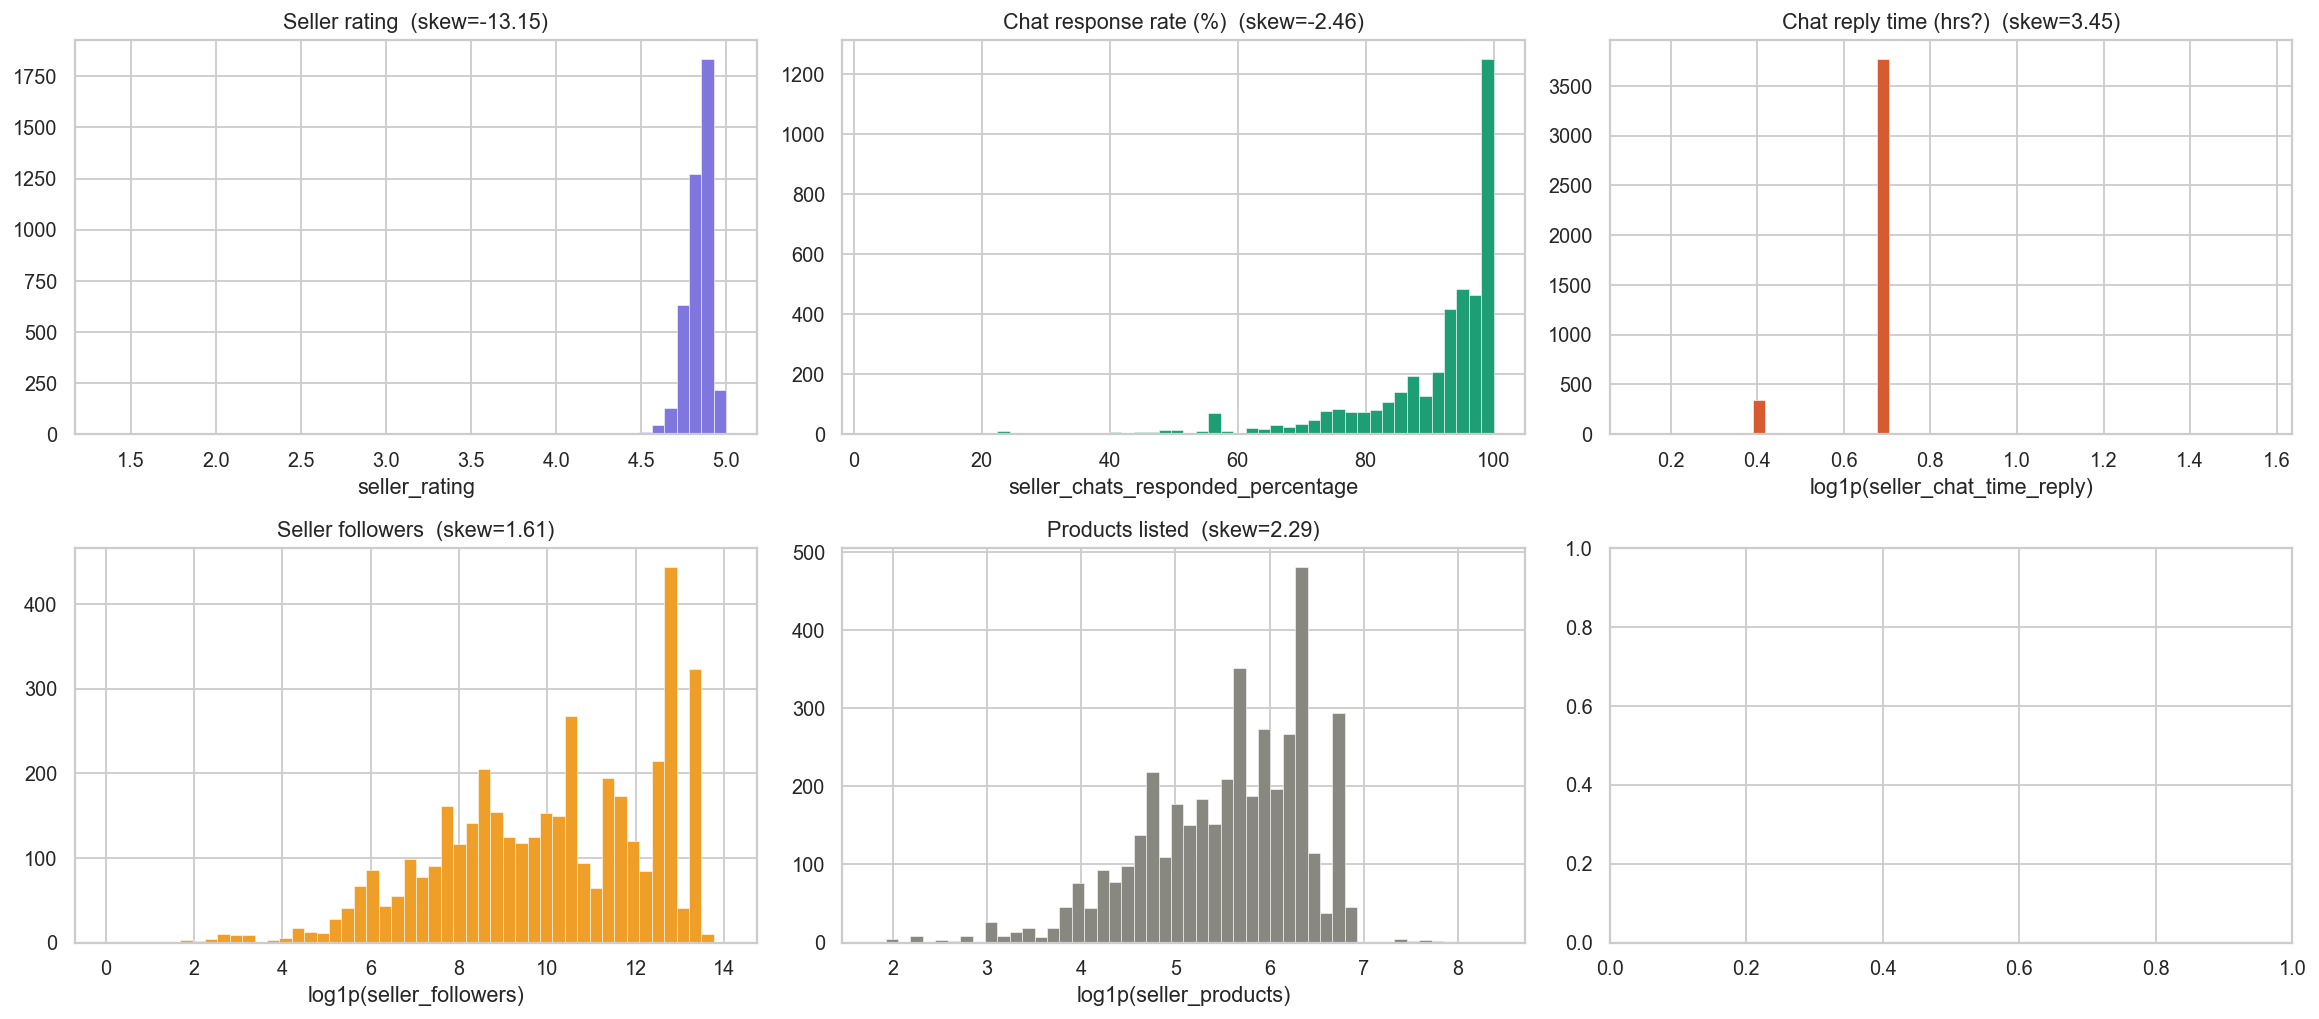


Sellers with ≥90% chat response rate: 2,897 (69.7%)
Sellers with 100% chat response rate : 887 (21.4%)


In [38]:
# ── Seller-level signals: response rate, followers, products ───────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

seller_cols = {
    'seller_rating'                      : (PURPLE, 'Seller rating'),
    'seller_chats_responded_percentage'  : (TEAL,   'Chat response rate (%)'),
    'seller_chat_time_reply'             : (CORAL,  'Chat reply time (hrs?)'),
    'seller_followers'                   : (AMBER,  'Seller followers'),
    'seller_products'                    : (GRAY,   'Products listed'),
}

for ax, (col, (color, label)) in zip(axes.flatten(), seller_cols.items()):
    data = df[col].dropna()
    if data.skew() > 1:
        data = np.log1p(data)
        xlabel = f'log1p({col})'
    else:
        xlabel = col

    ax.hist(data, bins=50, color=color, edgecolor='white', lw=0.3)
    ax.set_title(f'{label}  (skew={df[col].skew():.2f})')
    ax.set_xlabel(xlabel)

plt.tight_layout()
plt.show()

# Response rate: what fraction of sellers reply to >90% of chats?
resp_90 = (df['seller_chats_responded_percentage'] >= 90).sum()
print(f"\nSellers with ≥90% chat response rate: {resp_90:,} ({resp_90/len(df)*100:.1f}%)")
resp_100 = (df['seller_chats_responded_percentage'] == 100).sum()
print(f"Sellers with 100% chat response rate : {resp_100:,} ({resp_100/len(df)*100:.1f}%)")

#### [Insight] Chat response rate is right-skewed toward 95–100% — meaning most active sellers already respond at near-perfect rates.

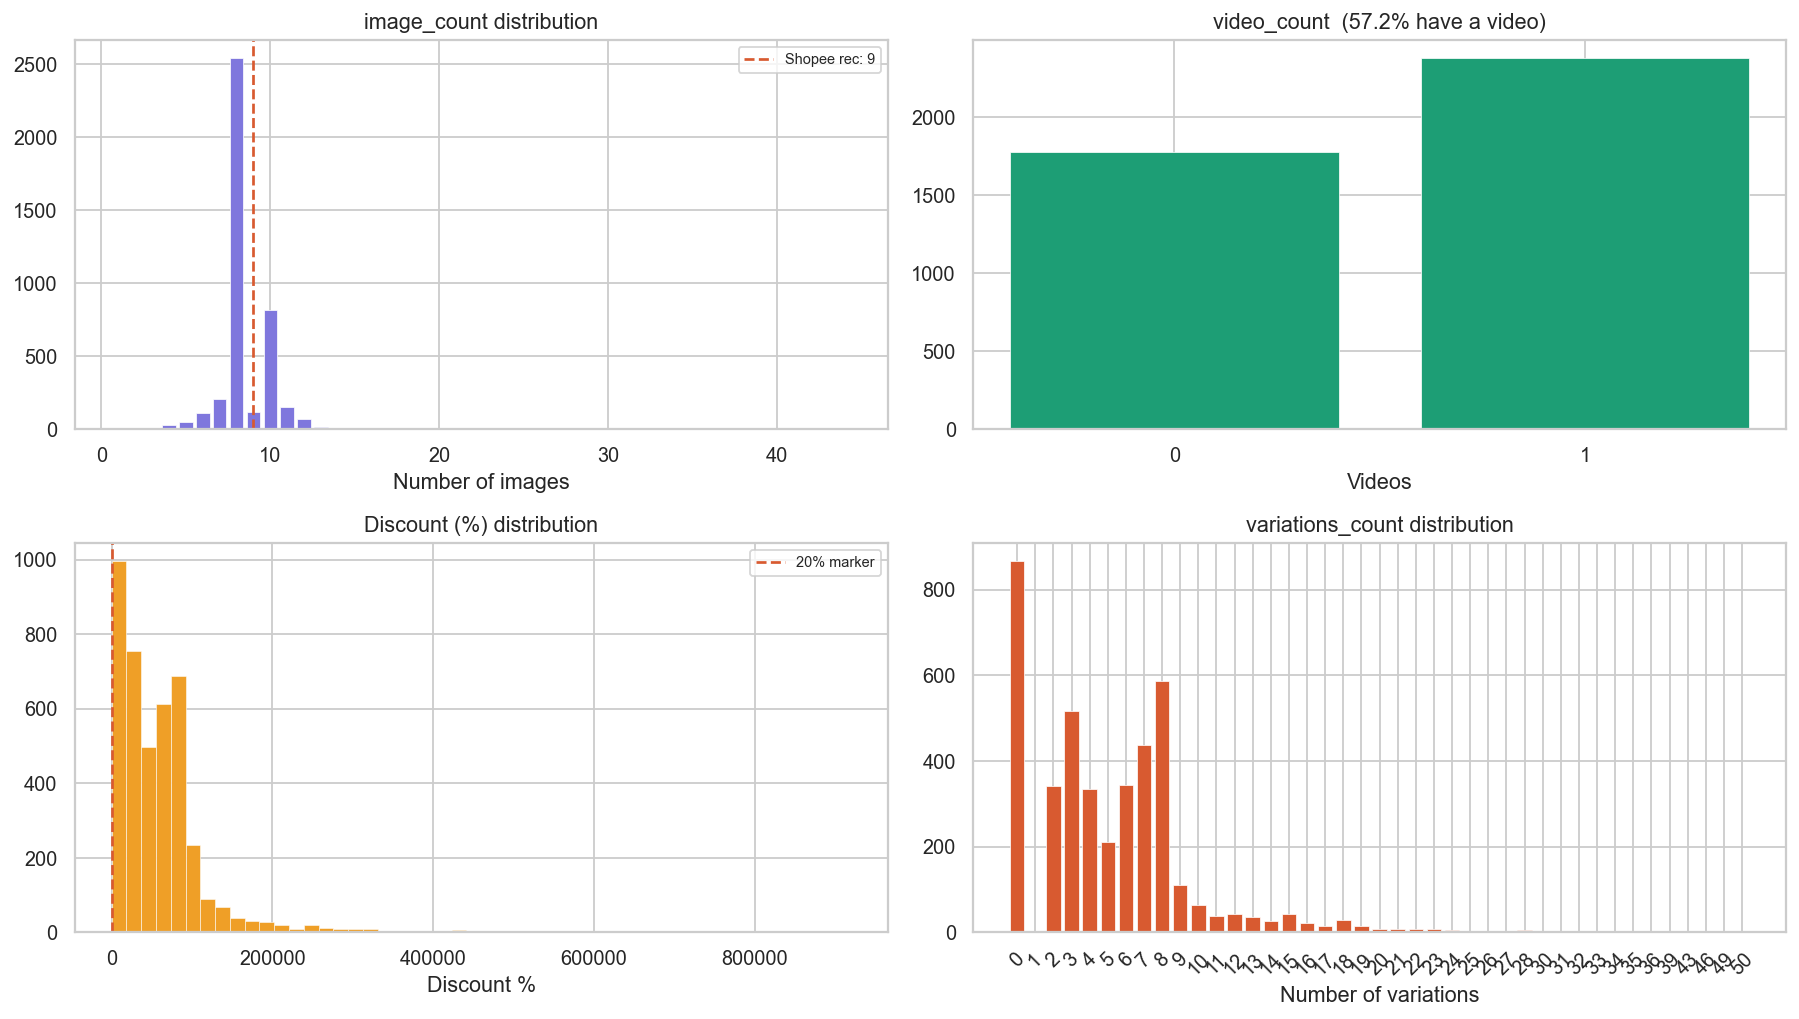


── Listing quality audit ──
  Has video              : 2,377 (57.2%)
  Has voucher            : 7 (0.2%)
  ≥9 images              : 1,219 (29.3%)
  Discount > 0           : 4,095 (98.6%)
  Multiple variations    : 3,284 (79.1%)


In [39]:
# ── Image count, video, discount, variations ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (a) image_count — Shopee recommends ≥9
img_vc = df['image_count'].value_counts().sort_index()
axes[0,0].bar(img_vc.index, img_vc.values, color=PURPLE, edgecolor='white', lw=0.4)
axes[0,0].axvline(9, color=CORAL, lw=1.5, linestyle='--', label='Shopee rec: 9')
axes[0,0].set_title('image_count distribution')
axes[0,0].set_xlabel('Number of images')
axes[0,0].legend(fontsize=8)

# (b) video_count — binary mostly (0 or 1)
vid_vc = df['video_count'].value_counts().sort_index()
axes[0,1].bar(vid_vc.index.astype('str'), vid_vc.values, color=TEAL, edgecolor='white', lw=0.4)
axes[0,1].set_title(f'video_count  ({(df["video_count"]>0).sum()/len(df)*100:.1f}% have a video)')
axes[0,1].set_xlabel('Videos')

# (c) discount distribution
axes[1,0].hist(df['discount'], bins=50, color=AMBER, edgecolor='white', lw=0.3)
axes[1,0].axvline(20, color=CORAL, lw=1.5, linestyle='--', label='20% marker')
axes[1,0].set_title('Discount (%) distribution')
axes[1,0].set_xlabel('Discount %')
axes[1,0].legend(fontsize=8)

# (d) variations_count
var_vc = df['variations_count'].value_counts().sort_index()
axes[1,1].bar(var_vc.index.astype('str'), var_vc.values, color=CORAL, edgecolor='white', lw=0.4)
axes[1,1].set_title('variations_count distribution')
axes[1,1].set_xlabel('Number of variations')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Quick listing quality scorecard
print("\n── Listing quality audit ──")
print(f"  Has video              : {(df['video_count']>0).sum():,} ({(df['video_count']>0).mean()*100:.1f}%)")
print(f"  Has voucher            : {df['voucher_status'].sum():,} ({df['voucher_status'].mean()*100:.1f}%)")
print(f"  ≥9 images              : {(df['image_count']>=9).sum():,} ({(df['image_count']>=9).mean()*100:.1f}%)")
print(f"  Discount > 0           : {(df['discount']>0).sum():,} ({(df['discount']>0).mean()*100:.1f}%)")
print(f"  Multiple variations    : {(df['variations_count']>1).sum():,} ({(df['variations_count']>1).mean()*100:.1f}%)")

#### [Insight] image_count spike at 9–10 (Shopee's recommended max), and a binary "has_video" will likely separate top-tier listings. 

In [40]:
# ── Consolidate findings into a decisions table ───────────────────
decisions = [
    ('rating',             'Left-compressed [0, 5]',    'Keep raw; exclude rating==0 rows'),
    ('final_price',        'Strong right skew',         'log1p transform'),
    ('reviews',            'Extreme right skew',        'log1p transform'),
    ('sold',               'Extreme right skew',        'log1p transform'),
    ('gmv_cal',            'Extreme right skew',        'log1p + qcut → gmv_tier (target)'),
    ('stock',              'Strong right skew',         'log1p transform'),
    ('favorites',          'Strong right skew',         'log1p transform'),
    ('seller_followers',   'Strong right skew',         'log1p transform'),
    ('discount',           'Bimodal (0% + spread)',     'Keep + add has_discount flag'),
    ('image_count',        'Right-skewed, peaks at 9',  'Keep + add meets_image_rec flag'),
    ('video_count',        'Near-binary (0 or 1)',      'Convert to has_video boolean'),
    ('voucher_status',     'Binary',                    'Already int8 — use as-is'),
    ('variations_count',   'Right-skewed',              'Keep raw or bin into 1/2–4/5+'),
    ('seller_chats_%',     'Left-compressed near 100',  'Binarise at ≥95% threshold'),
    ('seller_chat_time',   'Right-skewed',              'log1p transform'),
    ('seller_joined_date', 'Datetime',                  'Convert → seller_age_days (int)'),
    ('price_band',         'Created this phase',        'One-hot encode in Phase 6'),
    ('gmv_tier',           'Created this phase',        'Classification target (Phase 7)'),
]

dec_df = pd.DataFrame(decisions, columns=['Feature', 'Distribution shape', 'Phase 6 action'])
display(dec_df.style.set_caption('Phase 2 → Phase 6 engineering decisions')
                    .set_properties(**{'text-align': 'left'})
                    .hide(axis='index'))

Feature,Distribution shape,Phase 6 action
rating,"Left-compressed [0, 5]",Keep raw; exclude rating==0 rows
final_price,Strong right skew,log1p transform
reviews,Extreme right skew,log1p transform
sold,Extreme right skew,log1p transform
gmv_cal,Extreme right skew,log1p + qcut → gmv_tier (target)
stock,Strong right skew,log1p transform
favorites,Strong right skew,log1p transform
seller_followers,Strong right skew,log1p transform
discount,Bimodal (0% + spread),Keep + add has_discount flag
image_count,"Right-skewed, peaks at 9",Keep + add meets_image_rec flag


In [41]:
df.describe()

,id,rating,reviews,initial_price,final_price,stock,favorite,seller_rating,seller_products,seller_chats_responded_percentage,seller_chat_time_reply,seller_joined_date,seller_followers,sold,gmv_cal,coin_slot,variations_count,voucher_status,image_count,video_count,discount,log_reviews,log_gmv,log_favorite,log_rating,log_sold,rating_credibility
count,4.154000e+03,4154.000000,4154.000000,4.154000e+03,4154.000000,4.154000e+03,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154,4.154000e+03,4154.000000,4.154000e+03,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000,4154.000000
mean,1.452962e+10,4.848830,451.757583,1.412304e+05,83143.488880,2.227453e+03,114.065479,4.836810,346.468223,90.165383,0.966278,1970-01-01 00:00:05.266387847,1.390045e+05,750.288397,4.921387e+07,0.180067,5.236639,0.001685,8.597256,0.572220,58086.911821,3.605694,15.235652,3.304428,1.764624,4.314232,2.105201
min,2.438520e+07,0.000000,0.000000,5.000000e+03,3999.000000,0.000000e+00,0.000000,1.350000,5.000000,3.000000,0.140000,1970-01-01 00:00:00.104038329,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.113811e+09,4.810000,5.000000,8.500000e+04,52000.000000,1.000000e+01,6.000000,4.800000,149.250000,87.000000,1.000000,1970-01-01 00:00:04,4.092500e+03,11.000000,7.620750e+05,0.000000,2.000000,0.000000,8.000000,0.000000,20000.000000,1.791759,13.543802,1.945910,1.759581,2.484907,0.249792
50%,1.643621e+10,4.890000,29.000000,1.300000e+05,70000.000000,9.200000e+01,26.000000,4.850000,285.000000,95.000000,1.000000,1970-01-01 00:00:06,2.860000e+04,67.000000,4.593625e+06,0.000000,5.000000,0.000000,8.000000,1.000000,50000.000000,3.401197,15.340180,3.295837,1.773256,4.219508,1.383738
75%,2.093548e+10,5.000000,156.750000,1.750000e+05,89900.000000,7.025000e+02,110.750000,4.890000,517.000000,99.000000,1.000000,1970-01-01 00:00:07,2.326000e+05,373.000000,2.638970e+07,0.000000,8.000000,0.000000,10.000000,1.000000,79000.000000,5.061008,17.088484,4.716257,1.791759,5.924256,4.443155
max,2.886636e+10,5.000000,49830.000000,1.339000e+06,600000.000000,1.727036e+06,997.000000,5.000000,4356.000000,100.000000,3.780000,1970-01-01 00:00:10.050650239,1.266960e+06,54813.000000,5.746629e+09,1.000000,50.000000,1.000000,44.000000,1.000000,920000.000000,10.816393,22.471879,6.905753,1.791759,10.911701,4.977475
std,7.210249e+09,0.260291,2109.167409,9.970318e+04,60346.839436,3.084009e+04,198.043603,0.093631,261.545978,13.362740,0.184656,NaN,2.036868e+05,2520.027677,1.961050e+08,0.384290,4.884468,0.041021,2.025910,0.494816,57859.541273,2.159541,2.734426,1.883254,0.066438,2.263469,1.924284


In [42]:
print(df.columns.tolist())

['id', 'title', 'rating', 'reviews', 'initial_price', 'final_price', 'stock', 'favorite', 'seller_name', 'breadcrumb', 'seller_rating', 'seller_products', 'seller_chats_responded_percentage', 'seller_chat_time_reply', 'seller_joined_date', 'seller_followers', 'sold', 'brand', 'gmv_cal', 'motif', 'warranty_type', 'material', 'warranty_duration', 'country_of_origin', 'closure_type', 'card_slots', 'coin_slot', 'leather_texture', 'leather_finish', 'leather_type', 'shipped_from_region', 'variations_count', 'voucher_status', 'image_count', 'video_count', 'discount', 'wallet_type', 'log_reviews', 'log_gmv', 'log_favorite', 'log_rating', 'log_sold', 'rating_credibility', 'price_band', 'gmv_tier']


In [43]:
categorical_features_raw = [
    'wallet_type', 'material', 'motif', 'leather_texture',
    'leather_finish', 'leather_type', 'closure_type', 'card_slots',
    'coin_slot', 'country_of_origin', 'shipped_from_region',
    'warranty_type', 'warranty_duration', 'voucher_status',
]
cat_cols = [c for c in categorical_features_raw if c in df.columns]
print(f"Categorical columns found: {cat_cols}\n")

Categorical columns found: ['wallet_type', 'material', 'motif', 'leather_texture', 'leather_finish', 'leather_type', 'closure_type', 'card_slots', 'coin_slot', 'country_of_origin', 'shipped_from_region', 'warranty_type', 'warranty_duration', 'voucher_status']



In [51]:
TOP_N     = 12    # max categories per chart
MIN_COUNT =  5   # min listings per category to show

def plot_category_metric(
    df, cat_cols, metric, agg_func,
    title, xlabel, color,
    top_n=TOP_N, min_count=MIN_COUNT
):
    """
    Grid of horizontal bar charts — one panel per categorical column.

    Parameters
    ----------
    metric    : column to aggregate
    agg_func  : 'sum' | 'mean' | 'median' | 'count'
    """
    n_grid_cols = 2
    n_grid_rows = (len(cat_cols) + 1) // n_grid_cols

    fig, axes = plt.subplots(
        n_grid_rows, n_grid_cols,
        figsize=(20, n_grid_rows * 5.2)
    )
    axes = axes.flatten()

    for i, cat_col in enumerate(cat_cols):
        ax = axes[i]

        grp = (
            df.groupby(cat_col)[metric]
            .agg(['sum', 'mean', 'median', 'count'])
            .reset_index()
        )
        grp = grp[grp['count'] >= min_count]
        grp = grp.sort_values(agg_func, ascending=False).head(top_n)

        if grp.empty:
            ax.set_visible(False)
            continue

        # Reverse so highest bar sits at the top
        y_labels = grp[cat_col].astype(str).values[::-1]
        x_values = grp[agg_func].values[::-1]
        counts   = grp['count'].values[::-1]

        bars = ax.barh(y_labels, x_values, color=color,
                       edgecolor='white', linewidth=0.6)

        max_x = x_values.max() if x_values.max() != 0 else 1
        for bar, cnt in zip(bars, counts):
            ax.text(
                bar.get_width() + max_x * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f"n={int(cnt):,}",
                va='center', ha='left', fontsize=7.5, color='#666666'
            )

        ax.set_title(
            cat_col.replace('_', ' ').title(),
            fontsize=11, fontweight='bold', pad=6
        )
        ax.set_xlabel(xlabel, fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
        ax.tick_params(axis='y', labelsize=8.5)
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(x=0.18)

    for j in range(len(cat_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()

def fmt_k(x, _):
    """Readable axis labels: 12500 → 12K, 1_200_000 → 1.2M"""
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"{x/1_000:.0f}K"
    return f"{x:.1f}"

A. TOTAL SOLD BY CATEGORY


/var/folders/g_/fmz6fbfx0l96hfjsv2764ypw0000gn/T/ipykernel_3612/3346539442.py:72: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()


B. MEAN SOLD BY CATEGORY


/var/folders/g_/fmz6fbfx0l96hfjsv2764ypw0000gn/T/ipykernel_3612/3346539442.py:72: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/Users/angelinemarcellelukito/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  func(*args, **kwargs)
/Users/angelinemarcellelukito/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  func(*args, **kwargs)
/Users/angelinemarcellelukito/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


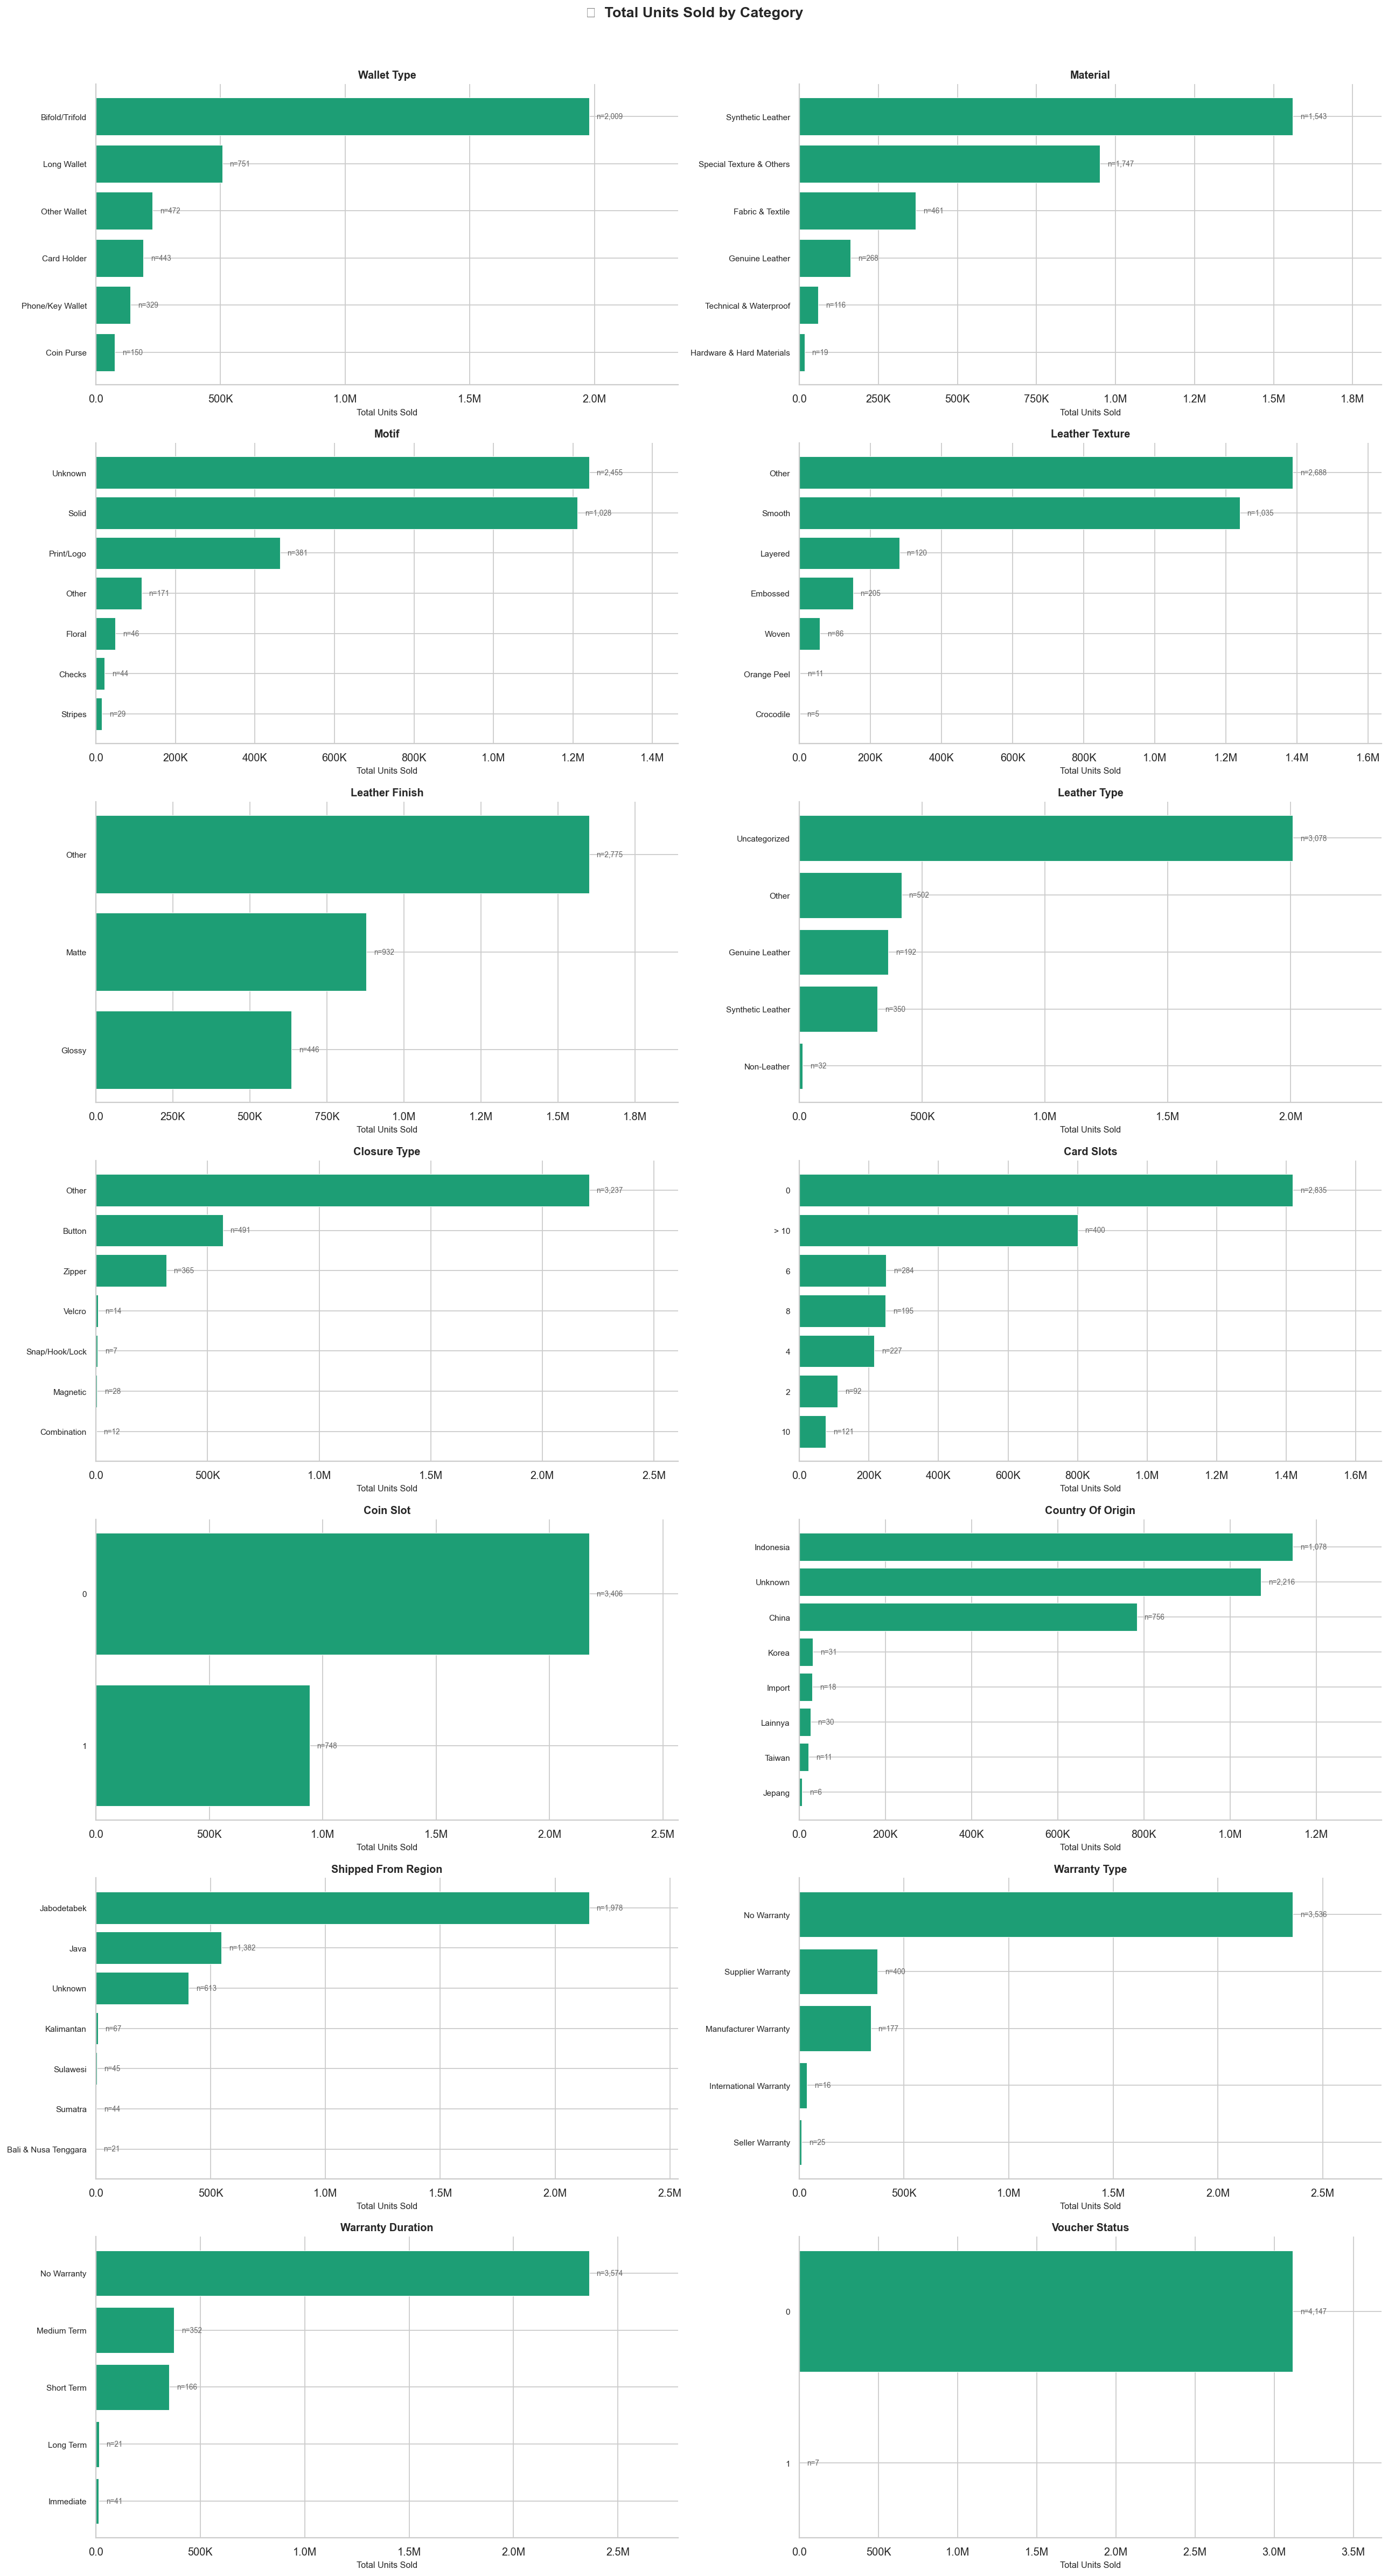

/Users/angelinemarcellelukito/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


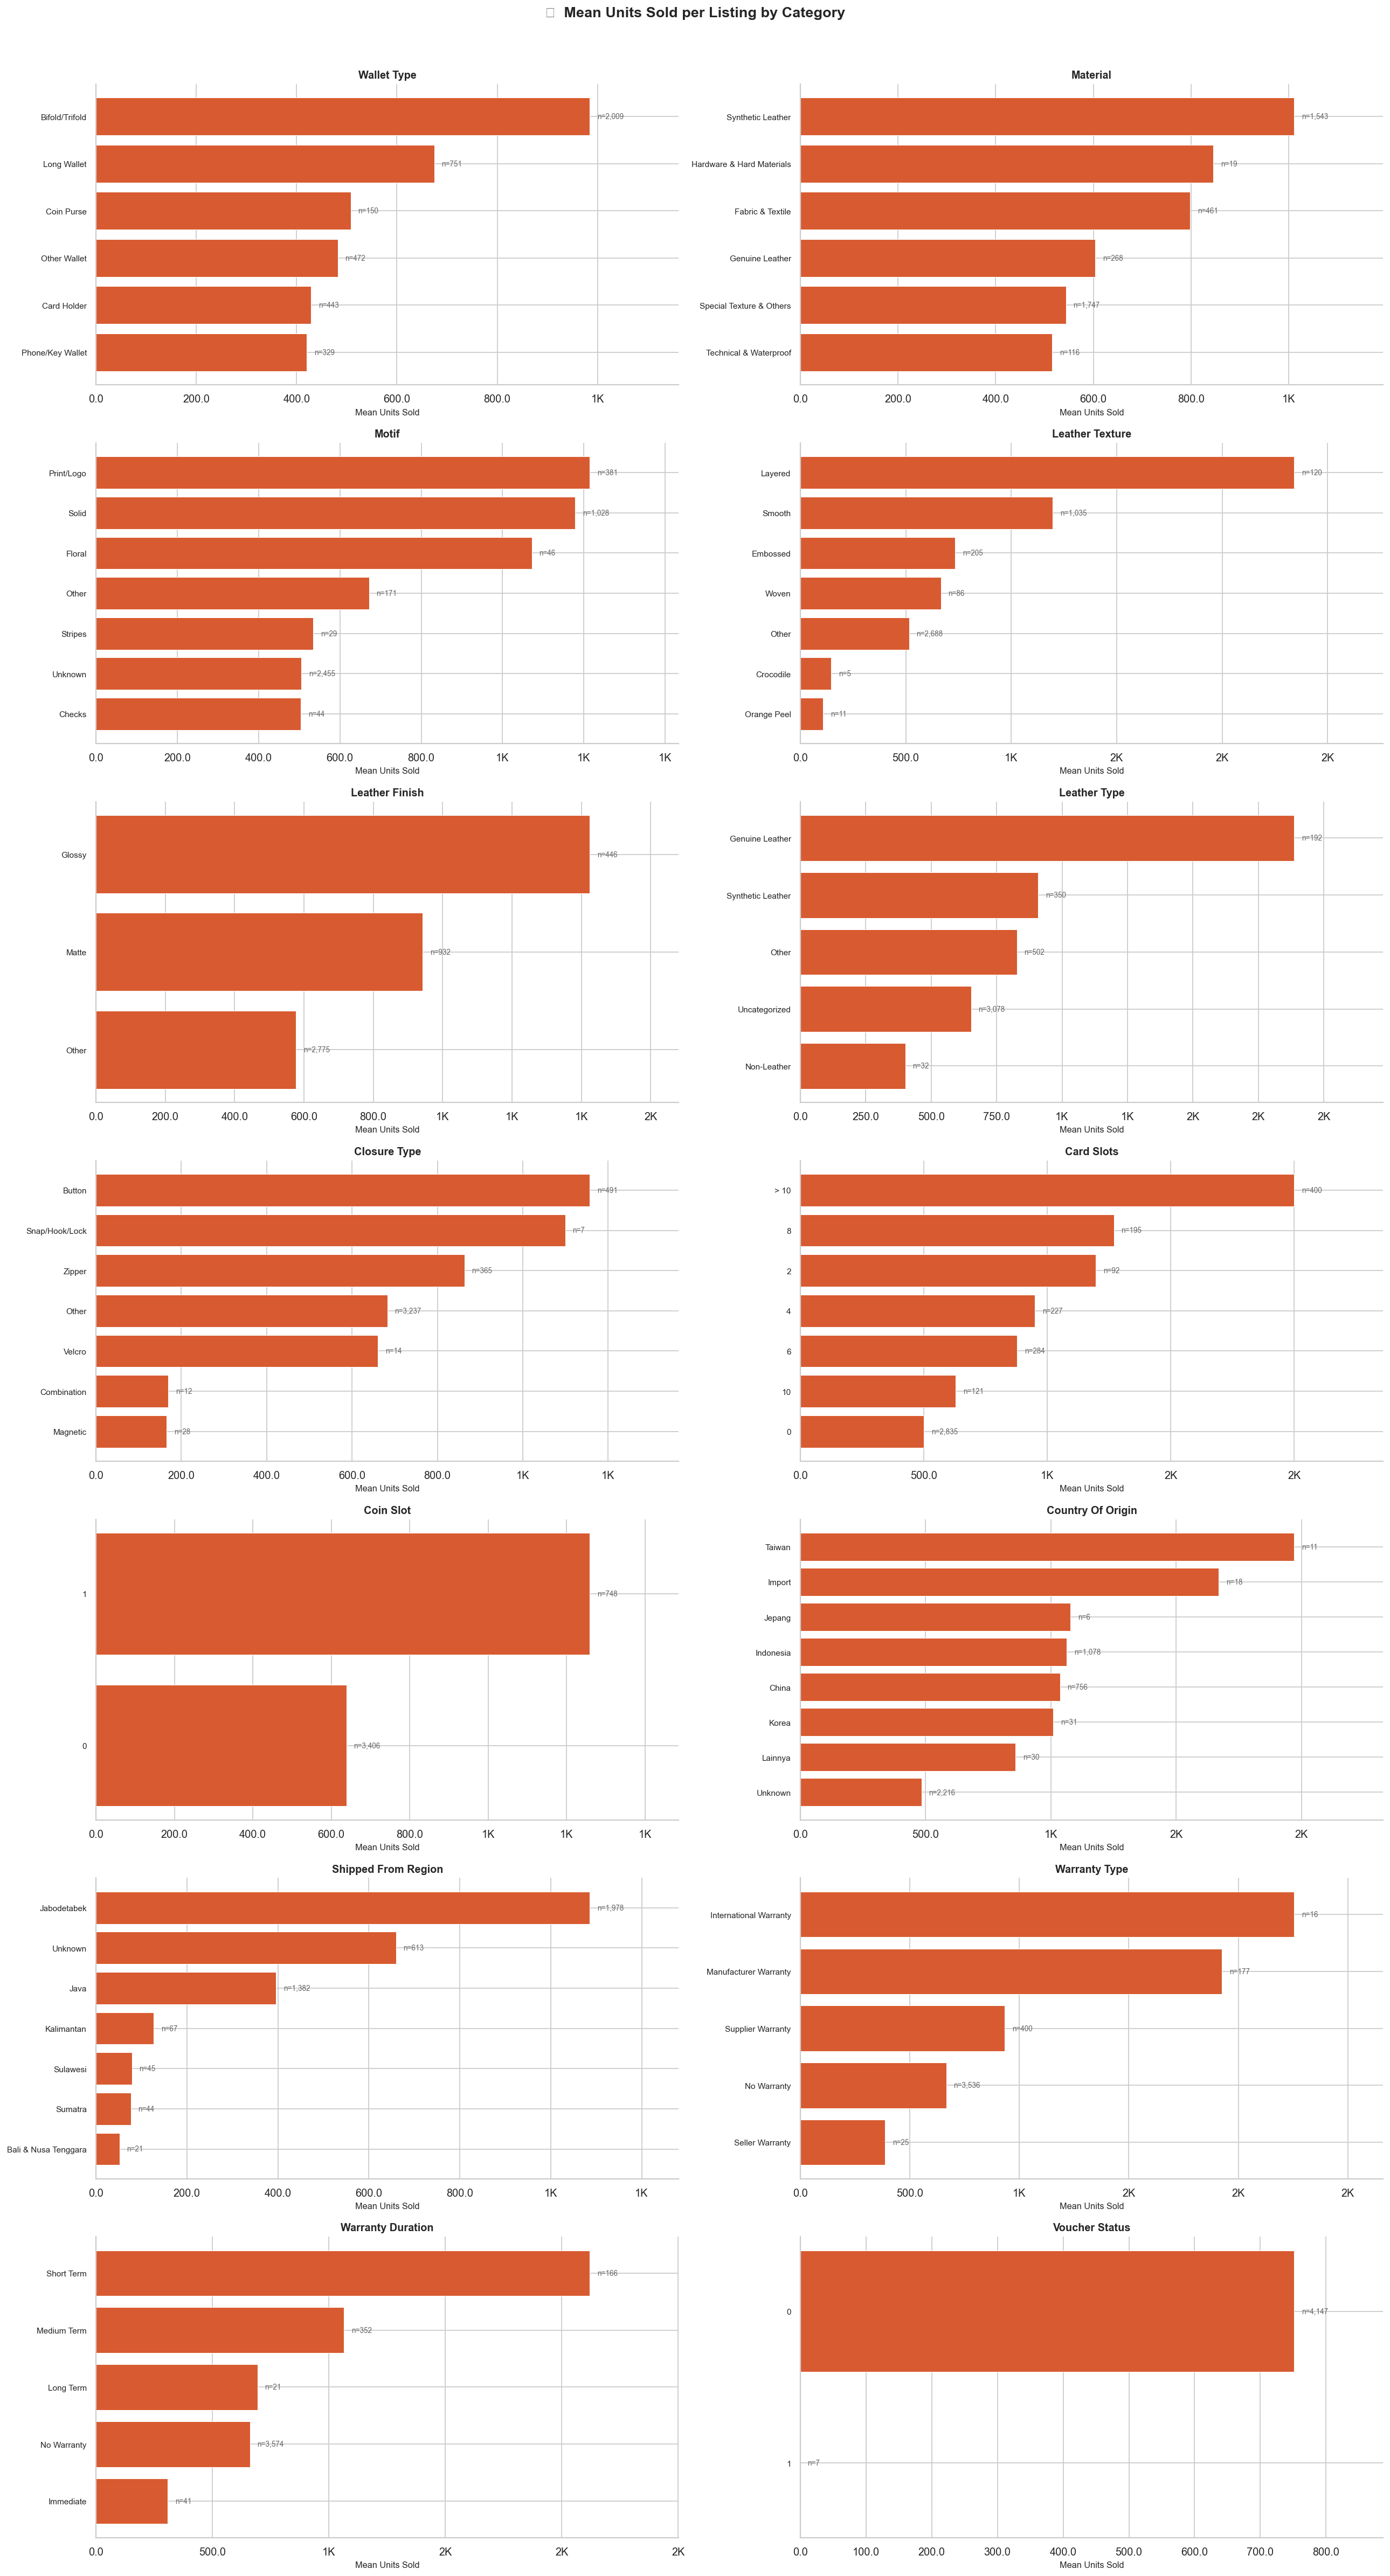

In [52]:
print("=" * 60)
print("A. TOTAL SOLD BY CATEGORY")
print("=" * 60)
plot_category_metric(
    df=df, cat_cols=cat_cols,
    metric='sold', agg_func='sum',
    title="📦  Total Units Sold by Category",
    xlabel="Total Units Sold",
    color=TEAL,
)

print("=" * 60)
print("B. MEAN SOLD BY CATEGORY")
print("=" * 60)
plot_category_metric(
    df=df, cat_cols=cat_cols,
    metric='sold', agg_func='mean',
    title="📊  Mean Units Sold per Listing by Category",
    xlabel="Mean Units Sold",
    color=CORAL,
)